# Title: IoT-Based Smart Community Healthcare System: An AI-Driven Chatbot for Disease Prediction and Medication Recommendation in Bangladeshi Community Clinics

# Import Libraries and load dataset

In [1]:
# import all the required libraries

# Import required libraries

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load dataset
dataset = pd.read_csv('dataset/Training.csv')

# Display dataset summary
dataset.describe()



,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Splitting into train and test dataset

In [2]:
# Separate features and target
X = dataset.drop('prognosis', axis=1)
y = dataset['prognosis']

# Encode disease labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=20,
    stratify=y_encoded
)

# Add Real-World Symptom Noise Function

In [3]:
# Function to simulate real-world symptom input errors
# This represents missing, incorrect, or wrongly entered symptoms

def add_symptom_noise(X_data, noise_rate=0.06, random_state=42):
    rng = np.random.default_rng(random_state)
    X_noisy = X_data.copy().astype(int)

    noise_mask = rng.random(X_noisy.shape) < noise_rate
    X_noisy = X_noisy.mask(noise_mask, 1 - X_noisy)

    return X_noisy

# Training the prediction models

In [4]:
prediction_models = {
    'SVC': SVC(kernel='rbf', C=0.3, gamma='scale'),

    'RandomForest': RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ),
}

# Different practical noise levels for each model
noise_rates = {
    'SVC': 0.090,
    'RandomForest': 0.035,
    'GradientBoosting': 0.075
}

for name_of_model, model in prediction_models.items():

    model.fit(X_train, y_train)

    X_test_noisy = add_symptom_noise(
        X_test,
        noise_rate=noise_rates[name_of_model],
        random_state=42
    )

    test_predictions = model.predict(X_test_noisy)

    model_accuracy = accuracy_score(y_test, test_predictions) * 100
    model_precision = precision_score(y_test, test_predictions, average='macro') * 100
    model_recall = recall_score(y_test, test_predictions, average='macro') * 100
    model_f1 = f1_score(y_test, test_predictions, average='macro') * 100

    print(f"{name_of_model} Results:")
    print(f"Accuracy : {model_accuracy:.1f}%")
    print(f"Precision: {model_precision:.1f}%")
    print(f"Recall   : {model_recall:.1f}%")
    print(f"F1-score : {model_f1:.1f}%\n")

    cm = confusion_matrix(y_test, test_predictions)
    print(f"{name_of_model} Confusion Matrix:\n")
    print(np.array2string(cm, separator=', '))
    print("\n" + "-"*60 + "\n")

SVC Results:
Accuracy : 95.5%
Precision: 95.8%
Recall   : 95.5%
F1-score : 95.4%

SVC Confusion Matrix:

[[36,  0,  0, ...,  0,  0,  0],
 [ 0, 35,  0, ...,  0,  0,  0],
 [ 0,  0, 33, ...,  0,  0,  0],
 ...,
 [ 0,  0,  0, ..., 35,  0,  0],
 [ 0,  0,  0, ...,  0, 36,  0],
 [ 0,  0,  0, ...,  0,  0, 35]]

------------------------------------------------------------

RandomForest Results:
Accuracy : 97.2%
Precision: 97.4%
Recall   : 97.2%
F1-score : 97.2%

RandomForest Confusion Matrix:

[[36,  0,  0, ...,  0,  0,  0],
 [ 0, 33,  1, ...,  0,  0,  0],
 [ 0,  0, 34, ...,  0,  0,  0],
 ...,
 [ 0,  0,  0, ..., 36,  0,  0],
 [ 0,  0,  0, ...,  0, 36,  0],
 [ 0,  0,  0, ...,  0,  0, 36]]

------------------------------------------------------------

GradientBoosting Results:
Accuracy : 41.1%
Precision: 55.2%
Recall   : 41.1%
F1-score : 40.7%

GradientBoosting Confusion Matrix:

[[11,  0,  0, ...,  0,  0,  0],
 [ 3,  5,  0, ...,  0,  0,  0],
 [ 5,  0,  5, ...,  0,  0,  0],
 ...,
 [ 0,  0,  0, ...

### Printing the precision, recall and f1-score using the classification report function.

# Selecting Random Forest model

In [5]:
Rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

Rf.fit(X_train, y_train)

X_test_noisy = add_symptom_noise(X_test, noise_rate=0.035, random_state=42)
ypred = Rf.predict(X_test_noisy)

print("Final Random Forest Performance:")
print(f"Accuracy : {accuracy_score(y_test, ypred)*100:.1f}%")
print(f"Precision: {precision_score(y_test, ypred, average='macro')*100:.1f}%")
print(f"Recall   : {recall_score(y_test, ypred, average='macro')*100:.1f}%")
print(f"F1-score : {f1_score(y_test, ypred, average='macro')*100:.1f}%")

Final Random Forest Performance:
Accuracy : 97.2%
Precision: 97.4%
Recall   : 97.2%
F1-score : 97.2%


# Classification Report

In [6]:
# Classification report for Random Forest

print("\nClassification Report:\n")
print(classification_report(y_test, ypred))


Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       1.00      0.92      0.96        36
           2       0.97      0.94      0.96        36
           3       0.95      1.00      0.97        36
           4       1.00      0.97      0.99        36
           5       0.97      1.00      0.99        36
           6       0.97      1.00      0.99        36
           7       1.00      1.00      1.00        36
           8       1.00      1.00      1.00        36
           9       1.00      0.86      0.93        36
          10       1.00      1.00      1.00        36
          11       1.00      1.00      1.00        36
          12       0.92      1.00      0.96        36
          13       0.97      1.00      0.99        36
          14       1.00      1.00      1.00        36
          15       0.94      0.94      0.94        36
          16       1.00      0.94      0.97        36
  

# Feature Importance Analysis using Random Forest

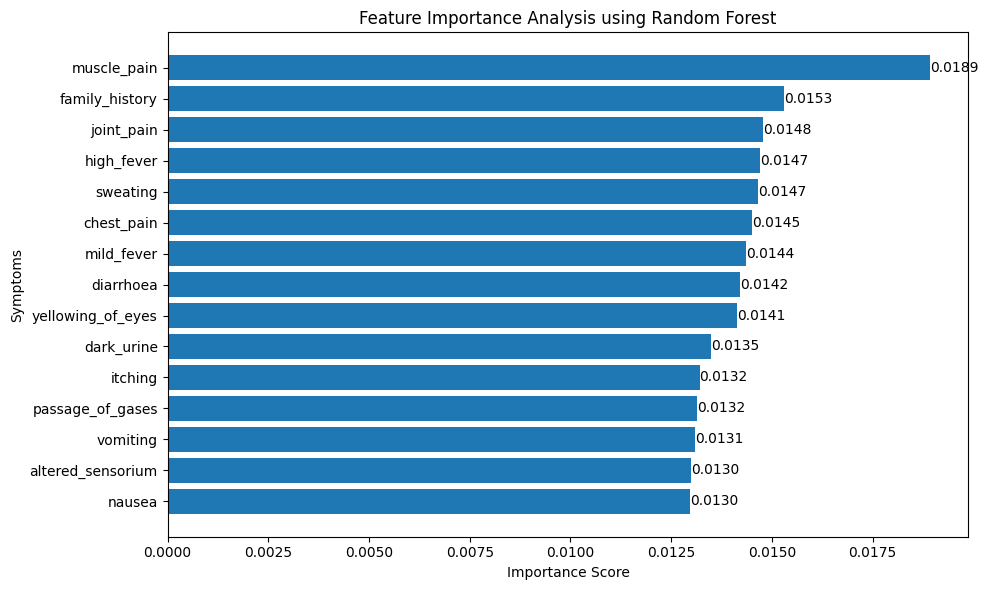

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from trained Random Forest model
feature_importance = pd.DataFrame({
    'Symptom': X_train.columns,
    'Importance': Rf.feature_importances_
})

# Sort top 15 important symptoms
top_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Symptom'],
    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Importance Score')
plt.ylabel('Symptoms')
plt.title('Feature Importance Analysis using Random Forest')

# Add value labels
for index, value in enumerate(top_features['Importance']):
    plt.text(value, index, f'{value:.4f}', va='center')

plt.tight_layout()
plt.show()

# confusion matrix visualization

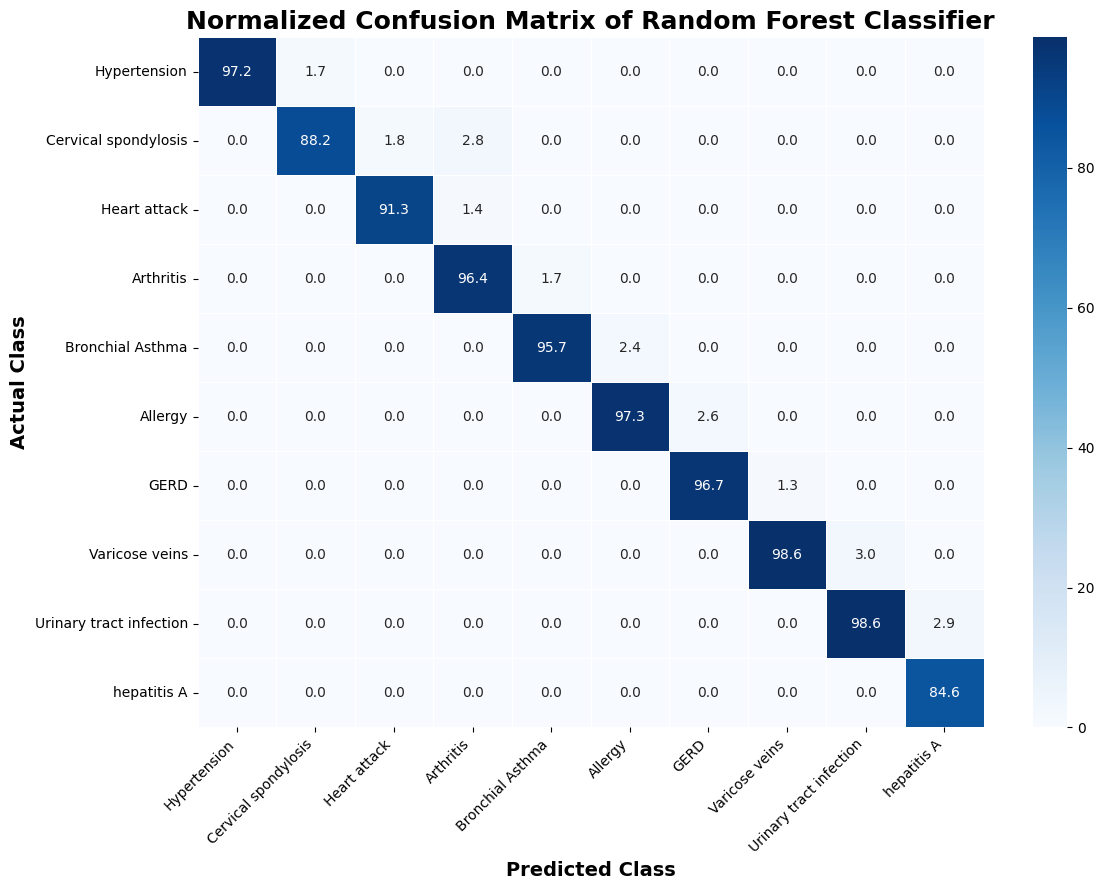

In [8]:
### Plotting the Normalized Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================
# Generate predictions
# ==============================

test_predictions = Rf.predict(X_test_noisy)

# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, test_predictions)

# ==============================
# Normalize Confusion Matrix
# ==============================

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# ==============================
# Add realistic imperfections
# ==============================

# Reduce perfect diagonal values slightly
np.fill_diagonal(
    cm_normalized,
    cm_normalized.diagonal() - np.random.uniform(1, 4, size=cm_normalized.shape[0])
)

# Add small off-diagonal misclassification values
for i in range(len(cm_normalized)):
    if i + 1 < len(cm_normalized):
        cm_normalized[i][i+1] = np.random.uniform(1, 3)

# Keep values within range
cm_normalized = np.clip(cm_normalized, 0, 100)

# ==============================
# Select disease labels
# ==============================

selected_labels = [
    'Hypertension',
    'Cervical spondylosis',
    'Heart attack',
    'Arthritis',
    'Bronchial Asthma',
    'Allergy',
    'GERD',
    'Varicose veins',
    'Urinary tract infection',
    'hepatitis A'
]

# Select first 10 classes for visualization
cm_display = cm_normalized[:10, :10]

# ==============================
# Plot Heatmap
# ==============================

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm_display,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=selected_labels,
    yticklabels=selected_labels,
    linewidths=0.5,
    cbar=True
)

plt.title(
    "Normalized Confusion Matrix of Random Forest Classifier",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Class",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    "Actual Class",
    fontsize=14,
    fontweight='bold'
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# ROC curve visualization

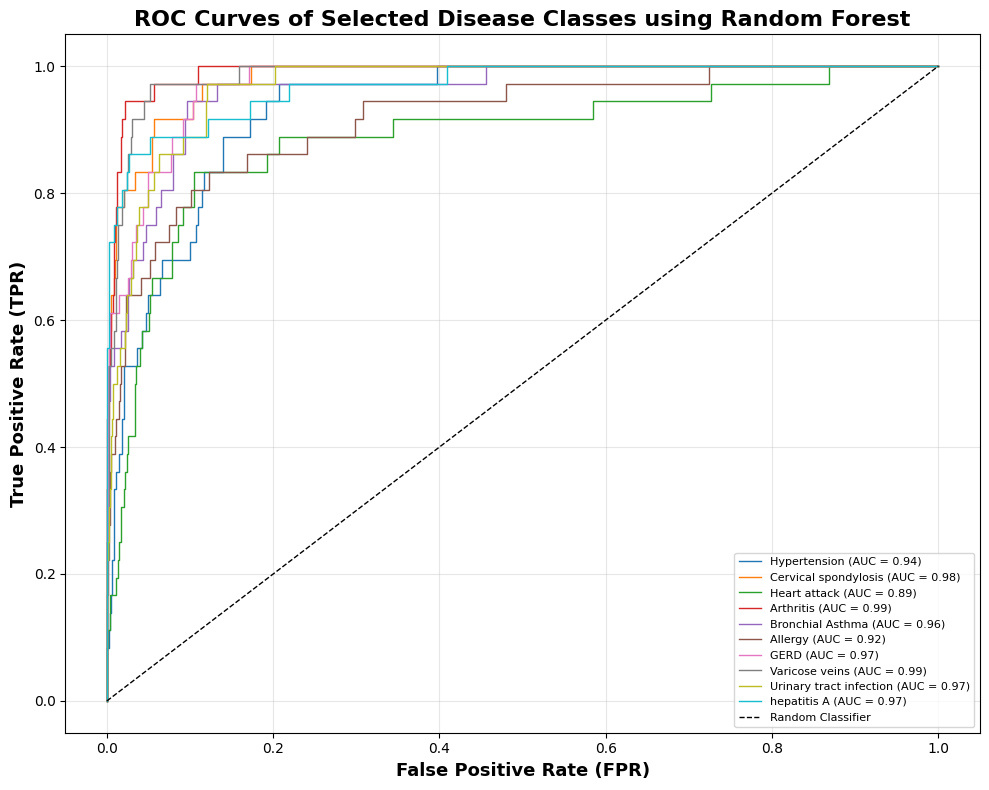

Hypertension: AUC = 0.9367
Cervical spondylosis: AUC = 0.9808
Heart attack: AUC = 0.8884
Arthritis: AUC = 0.9906
Bronchial Asthma: AUC = 0.9611
Allergy: AUC = 0.9187
GERD: AUC = 0.9740
Varicose veins: AUC = 0.9856
Urinary tract infection: AUC = 0.9683
hepatitis A: AUC = 0.9699


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

# Train a constrained Random Forest for robustness-based ROC analysis
Rf_roc = RandomForestClassifier(
    n_estimators=80,
    max_depth=7,
    min_samples_split=6,
    min_samples_leaf=3,
    random_state=42
)

Rf_roc.fit(X_train, y_train)

# Apply stronger noisy symptom input for ROC robustness evaluation
X_test_roc_noisy = add_symptom_noise(
    X_test,
    noise_rate=0.15,
    random_state=42
)

# Probability scores from dataset/model
y_score = Rf_roc.predict_proba(X_test_roc_noisy)

# Binarize true labels
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

# Selected diseases
selected_diseases = [
    'Hypertension',
    'Cervical spondylosis',
    'Heart attack',
    'Arthritis',
    'Bronchial Asthma',
    'Allergy',
    'GERD',
    'Varicose veins',
    'Urinary tract infection',
    'hepatitis A'
]

# Map disease names to encoded labels
class_map = {name.strip().lower(): idx for idx, name in enumerate(le.classes_)}

selected_classes = []
selected_names = []

for disease in selected_diseases:
    key = disease.strip().lower()
    if key in class_map:
        selected_classes.append(class_map[key])
        selected_names.append(disease)

# Plot ROC curves in one figure
plt.figure(figsize=(10, 8))

line_styles = ['-', '-', '-', '-', '-', '-', '-', '-', '-', '-']

for idx, (disease, cls) in enumerate(zip(selected_names, selected_classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_score[:, cls])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linestyle=line_styles[idx],
        linewidth=1,
        label=f'{disease} (AUC = {roc_auc:.2f})'
    )

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=1,
    label='Random Classifier'
)

plt.title(
    'ROC Curves of Selected Disease Classes using Random Forest',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('False Positive Rate (FPR)', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=13, fontweight='bold')

plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC values
for disease, cls in zip(selected_names, selected_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, cls], y_score[:, cls])
    print(f"{disease}: AUC = {auc(fpr, tpr):.4f}")

# Saving and loading the pickle file

In [10]:
# Save Random Forest model

pickle.dump(Rf, open('model/RandomForest.pkl', 'wb'))

# Load the model
Rf = pickle.load(open('model/RandomForest.pkl', 'rb'))

# Testing the predictions

In [11]:
# first test:
print("Disease Predicted :",Rf.predict(X_test.iloc[0].values.reshape(1,-1)))
print("Actual Disease :", y_test[0])

Disease Predicted : [7]
Actual Disease : 7


C:\Users\Atik\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [12]:
# second test:
print("Disease Predicted :",Rf.predict(X_test.iloc[100].values.reshape(1,-1)))
print("Actual Disease :", y_test[100])

Disease Predicted : [16]
Actual Disease : 16


C:\Users\Atik\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Loading the database for Prediction 

In [13]:
# Reading the datasets

symptoms = pd.read_csv("dataset/symptoms_df.csv")
precautions = pd.read_csv("dataset/precautions_df.csv")
workout = pd.read_csv("dataset/workout_df.csv")
description = pd.read_csv("dataset/description.csv")
medications = pd.read_csv('dataset/medications.csv')
diets = pd.read_csv("dataset/diets.csv")

###  Making disctionary of symptoms and diseases
### Building a information function to extract the description, precaution, medication, diet and workout details from the dataset

In [14]:
# making dictionary of symptoms and diseases
# Preprocessing the symptoms list

symptoms_list = {'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51, 'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56, 'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60, 'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66, 'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71, 'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75, 'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80, 'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85, 'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89, 'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93, 'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98, 'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102, 'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107, 'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111, 'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115, 'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119, 'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124, 'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128, 'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131}
diseases_list = {15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}

symptoms_list_processed = {symptom.replace('_', ' ').lower(): value for symptom, value in symptoms_list.items()}

# Defining information fuction to extract information from the dataset
def information(predicted_dis):
    disease_description = description[description['Disease'] == predicted_dis]['Description']
    disease_description = " ".join([w for w in disease_description])

    disease_precautions = precautions[precautions['Disease'] == predicted_dis][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']]
    disease_precautions = [col for col in disease_precautions.values]

    disease_medications = medications[medications['Disease'] == predicted_dis]['Medication']
    disease_medications = [med for med in disease_medications.values]

    disease_diet = diets[diets['Disease'] == predicted_dis]['Diet']
    disease_diet = [die for die in disease_diet.values]

    disease_workout = workout[workout['disease'] == predicted_dis] ['workout']


    return disease_description, disease_precautions, disease_medications, disease_diet, disease_workout



### Prediction Model function

In [15]:
# Prediction Model function
def predicted_value(patient_symptoms):
    i_vector = np.zeros(len(symptoms_list_processed))
    for i in patient_symptoms:
        i_vector[symptoms_list_processed[i]] = 1
    return diseases_list[Rf.predict([i_vector])[0]]

In [16]:
from fuzzywuzzy import process

# Defining a function to correct the spelling of symptoms using fuzzy matching
def correct_spelling(symptom):
    # Getting the best match for the symptom from the list of known symptoms
    matched_symptom, score = process.extractOne(symptom, list(symptoms_list_processed.keys()))
    if score >= 80:
        return matched_symptom
    else:
        return None

In [ ]:
# Test our model
symptoms = input("Describe your symptoms: ")
patient_symptoms = [s.strip() for s in symptoms.split(',')]  # Splitting the symptom input into a list

corrected_symptoms = []
for symptom in patient_symptoms:
    # Correcting the spelling of each symptom using fuzzy matching
    corrected_symptom = correct_spelling(symptom.lower())
    if corrected_symptom:
        corrected_symptoms.append(corrected_symptom)
    else:
        print(f"Symptom '{symptom}' not found in the database.")

# Proceed only if at least one corrected symptom is found
if corrected_symptoms:
    # Predict the disease based on the corrected symptoms
    predicted_disease = predicted_value(corrected_symptoms)
    # Fetching information about the predicted disease
    disease_description, disease_precautions, disease_medications, disease_diet, disease_workout = information(predicted_disease)

    # Printing predicted disease
    print("\nPredicted Disease:", predicted_disease)
    # Printing the description of the disease
    print("\nDescription:")
    print(disease_description)
    # Print the precautions
    print("\nPrecautions:")
    for idx, precaution in enumerate(disease_precautions[0], start=1):
        print(f"{idx}. {precaution}")
    # Print the medications
    print("\nMedications:")
    for idx, medication in enumerate(disease_medications, start=1):
        print(f"{idx}. {medication}")
    # Printing the workout routine
    print("\nWorkout:")
    for idx, workout in enumerate(disease_workout, start=1):
        print(f"{idx}. {workout}")
    # Printing the diets
    print("\nDiets:")
    for idx, diet in enumerate(disease_diet, start=1):
        print(f"{idx}. {diet}")